In [1]:
import pyforest
import scipy.stats as st

In [2]:
df= sns.load_dataset('tips')

<IPython.core.display.Javascript object>

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


The restuarent managers claims that the average total bill from his restaurent is $20
validate the claim at 95% level of confidence?

In [5]:
## Step1: State null and lternative hypothesis
# H0: mu= 20
# H1: mu !=20

In [6]:
mu=20

In [7]:
## Step 2: state or assumne confidence level(95%) or level of significance (5%)
alpha=0.05 # 1-confidence level #  1-0.95

In [8]:
## Step 3: find the test statistic from the sample data
# z_stat= (xbar-mu) / (sigma /sqrt(n)

In [9]:
xbar= df.total_bill.mean()
n= len(df.total_bill)
sigma = df.total_bill.std() ## since pop std is not known assuming sample std as population std.
std_error= sigma/np.sqrt(n)
z_stat= (xbar-mu)/std_error
z_stat

<IPython.core.display.Javascript object>

-0.37559294451919506

## 95% confidence interval
st.norm.interval(1-alpha, xbar, std_error) 

In [11]:
## Step 4 : find the critical values and compare test statisitc ; establish critical region
zalphaby2= st.norm.isf(alpha/2)
zalphaby2

1.9599639845400545

In [12]:
## step 5: Decision making or infering on population:
## 1. Critical Value Approach(CVA):
## if abs(test_statistic)< abs( critical value) --> fail to reject Ho 
 ## else reject H0

In the above problem abs(z_stat) =0.375 < abs(zalphhaby2) = 1.96 --> fail to reject H0;
Hence we conclude that the claim is true @ 5% level of significance

2. Confidence Interval Approach(CIA)
#if the assumed or hypothesis mean lies b/w the respective confidence interval --> fail to reject H0
 else reject H0;

In [15]:
## in the above problem the assumed mean =20 lies b/w 95% confidence interval ( 18.66 to 20.90)

## p -value approach(PVA):


In [17]:
pvalue= st.norm.cdf(z_stat)*2
pvalue

0.7072195368238168

In [18]:
## t and Z distributions
n= 244
zalphaby2= st.norm.isf(0.05/2)
talphaby2= st.t.isf(0.05/2, n-1)
print(zalphaby2, talphaby2)

1.9599639845400545 1.9697743954258797


In [19]:
## one sample t test 
st.ttest_1samp(df.total_bill, mu)

TtestResult(statistic=-0.37559294451919506, pvalue=0.7075471935626723, df=243)

## Two sample paramteric test - Independent 2 sample - z test and 2 sample independent t test

The restaurent manager is claiming that the average total bill is greater in dinner rather than in lunch time. Pls validate and verify the above statment @ 5% level of significance?

In [22]:
df.groupby('time')['total_bill'].describe()

C:\Users\malli\AppData\Local\Temp\ipykernel_36364\1293134793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('time')['total_bill'].describe()


,count,mean,std,min,25%,50%,75%,max
time,,,,,,,,
Lunch,68.0,17.168676,7.713882,7.51,12.2350,15.965,19.5325,43.11
Dinner,176.0,20.797159,9.142029,3.07,14.4375,18.390,25.2825,50.81


In [23]:
tb_lunch=df[df.time=='Lunch']['total_bill']
tb_dinner= df[df.time=='Dinner']['total_bill']

<IPython.core.display.Javascript object>

C:\Users\malli\AppData\Local\Temp\ipykernel_36364\3743016658.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tb_lunch)


<Axes: xlabel='total_bill', ylabel='Density'>

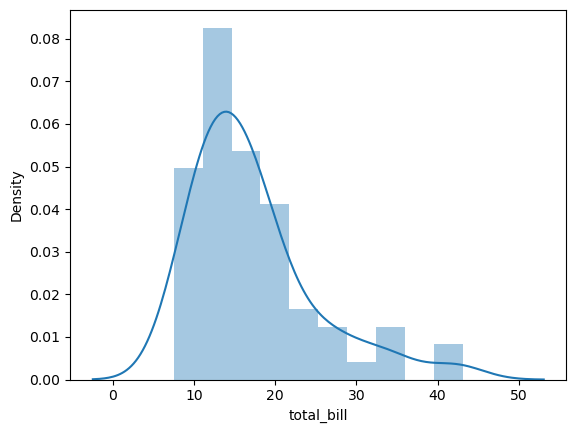

In [24]:
sns.distplot(tb_lunch)

<IPython.core.display.Javascript object>

C:\Users\malli\AppData\Local\Temp\ipykernel_36364\1656472625.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tb_dinner)


<Axes: xlabel='total_bill', ylabel='Density'>

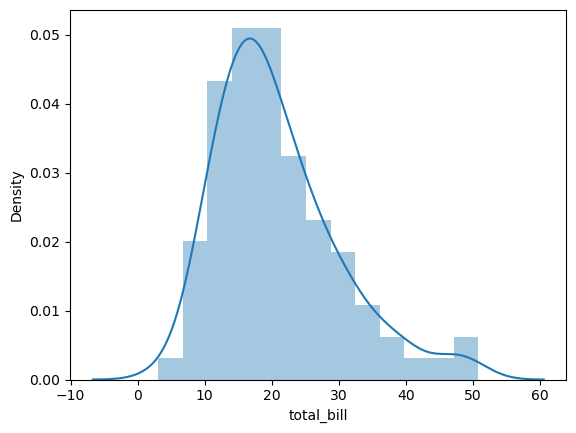

In [25]:
sns.distplot(tb_dinner)

since the sample size for lunch and dinner > 30 --> normality test is not required 

In [27]:
## Check the variance equality for the population data of lunch and dinner:
# H0: var_lunch = Var_ dinner
# H1: var_lunch != var_dinner
st.levene(tb_dinner, tb_lunch)

LeveneResult(statistic=2.6906995489829337, pvalue=0.1022346107726258)

In [28]:
# since p value(0.1) is > alpha ( 0.05) --> fail to reject H0; 
# Hence  we can conclude that the population variances of both lunch and dinner are same 

## Step 1: state your H0 & H1:
H0: mu_tb_dinnner<= mu_tb_lunch;

H1: mu_tb_dinner> mu_tb_lunch


In [30]:
## Step2: state your alpha
alpha=0.05

In [31]:
## step 3: find the test statistic:
st.ttest_ind(tb_dinner, tb_lunch, equal_var=True, alternative='greater')

TtestResult(statistic=2.8976375218366424, pvalue=0.002052310703797837, df=242.0)

In [32]:
st.t.sf(2.8976375218366424, 242)

0.002052310703797837

In [33]:
tb_m= df[df.sex=='Male']['total_bill']
tb_f= df[df.sex=='Female']['total_bill']

In [34]:
st.levene(tb_m,tb_f)

LeveneResult(statistic=1.631715567905501, pvalue=0.20269005267784254)

In [35]:
## pop variances are equal
## H0: mu_tb_male= mu_tb_female
## H1: mu_tb_male != mu _tb_female


In [36]:
st.ttest_ind(tb_m, tb_f, equal_var=True, alternative='two-sided')

TtestResult(statistic=2.2777940289803134, pvalue=0.0236116668468594, df=242.0)

In [37]:
## p value
st.t.sf(2.2777940289803134, 242)*2

0.0236116668468594

In [38]:
st.t.isf(0.05/2, 242)

1.9698151341345516

Test the claim that the weight reduction program is effective in reduction of weight with below sample data of 10 people @ 5% level of significance.
wt_before= np.array([90,87,67,99,110,88,78,77,97,100])
wt_after= np.array([80,77,77,89,90,78,78,87,87,90])

In [40]:
wt_before= np.array([90,87,67,99,110,88,78,77,97,100]) 
wt_after= np.array([80,77,77,89,90,78,78,87,87,90])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
print(np.mean(wt_after), np.mean(wt_before))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

83.3 89.3


In [42]:
diff= wt_before-wt_after
diff

array([ 10,  10, -10,  10,  20,  10,   0, -10,  10,  10])

In [43]:
# Step 0: Assumptions test
## Normality test
## check the normality for difference values
## Shapiro test :
## H0: pop data = normal ;
## H1: pop data != normal

<IPython.core.display.Javascript object>

C:\Users\malli\AppData\Local\Temp\ipykernel_36364\207595355.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff)


<Axes: ylabel='Density'>

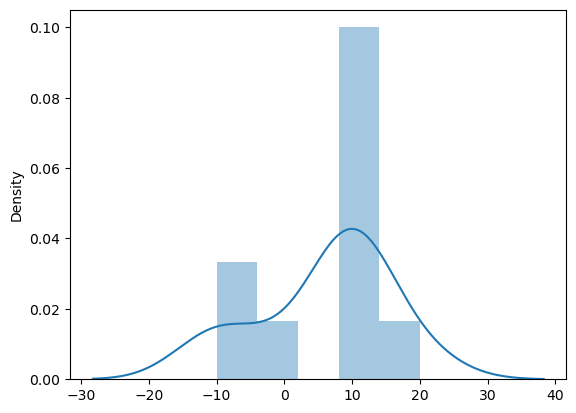

In [44]:
sns.distplot(diff)

In [45]:
st.shapiro(diff)

ShapiroResult(statistic=0.8007018955393095, pvalue=0.014786100185168585)

In [46]:
## since p value (0.01) < alpha --> reject H0;
# hence we can conclude that the population data in not normal
## so we have to proceed for non parametric test ( wilcoxon paired test)

In [47]:
## H0: pop median _diff <0
## H1: pop median_ diff >0 

In [48]:
st.wilcoxon(wt_before, wt_after,alternative='greater')

WilcoxonResult(statistic=36.0, pvalue=0.0416322583317752)

In [49]:
print(np.median(wt_after), np.median(wt_before))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

83.5 89.0


In [50]:
## in the above problem if we take alpha =0.01 ( 1%) then nomrality test will be passed.
## hence we can proceed for paramteric test

In [51]:
## H0: mu_diff_wt <=0
## H1: mu_diff_wt >0 

In [52]:
st.ttest_rel(wt_before, wt_after, alternative='greater')

TtestResult(statistic=1.9639610121239313, pvalue=0.04056309442292028, df=9)

In [53]:
st.ttest_1samp(diff, 0, alternative='greater')

TtestResult(statistic=1.9639610121239313, pvalue=0.04056309442292028, df=9)

since p value( 0.04) > alpha(0.01) ---> fail to reject H0;
Hence we can conclude that there is no much difference in the weight reduction. the weight reduction program is not effective.

is there a correlation b/w total bill and tip @ 5% level of significance?

In [56]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [57]:
st.pearsonr(df.total_bill, df.tip)

PearsonRResult(statistic=0.6757341092113645, pvalue=6.692470646863819e-34)

In [58]:
## Correlation test ( numerical vs Numerical)
## H0: 

In [59]:
st.spearmanr(wt_after, wt_before)

SignificanceResult(statistic=0.8098769172646004, pvalue=0.00451267151370922)

## Multiple samples test of Mean ( Analysis of Variance- ANOVA) 

Test the claim that the average total bill varies from Thu to Sun @ 1 % level of significance?

In [62]:
df.groupby('day')['total_bill'].describe()

C:\Users\malli\AppData\Local\Temp\ipykernel_36364\2137783598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['total_bill'].describe()


,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,17.682742,7.886170,7.51,12.4425,16.20,20.1550,43.11
Fri,19.0,17.151579,8.302660,5.75,12.0950,15.38,21.7500,40.17
Sat,87.0,20.441379,9.480419,3.07,13.9050,18.24,24.7400,50.81
Sun,76.0,21.410000,8.832122,7.25,14.9875,19.63,25.5975,48.17


In [63]:
tb_Thu=df[df.day=='Thur']['total_bill']
tb_Fri=df[df.day=='Fri']['total_bill']
tb_sat=df[df.day=='Sat']['total_bill']
tb_sun=df[df.day=='Sun']['total_bill']

In [64]:
## Normality test : only fri total bill to be tested
st.shapiro(tb_Fri)

ShapiroResult(statistic=0.8957935173266691, pvalue=0.04085649671549424)

since p value(0.04) > alpha(0.01) --> fail to reject H0;
Hence we can conclude that data is normal

In [66]:
## Variance Equality test: Levene test
st.levene(tb_Thu,tb_Fri,tb_sat,tb_sun)
          

LeveneResult(statistic=0.6653578279881612, pvalue=0.5740792267812198)

In [67]:
## H0:all the pop means of total bill for all the days are same;
## H1: any one po mean of total bill is different from the others;

In [68]:
alpha = 0.01

In [69]:
st.f_oneway(tb_Thu,tb_Fri,tb_sat,tb_sun)

F_onewayResult(statistic=2.7674794432863363, pvalue=0.04245383328952047)

In [70]:
st.f.isf(alpha,3, 244-4)

3.8642309599914926

# one sample z prooportion test

In the restaurent dataset problem, the managers claims that the smoking proportion of transactions is 40% , pls validate the claim @ 5% level of significance

In [130]:
df.smoker.value_counts(normalize=True)

smoker
No     0.618852
Yes    0.381148
Name: proportion, dtype: float64

In [ ]:
H0: P= 0.4
H1: P= !=0.4

In [206]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [134]:
df.smoker.value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [236]:
count= 93
n_obs= len(df)
P=0.40
alpha=0.05

In [238]:
z_stat, p_value=proportions_ztest(count,n_obs,P)
print(z_stat, p_value)

-0.6063491832694735 0.5442829052719291


In [240]:
# manual calculation
p= count/n_obs
std_error= np.sqrt(p*(1-p)/len(df))
z_statm= (p-P)/std_error
p_valuem= st.norm.sf(abs(z_statm))*2
print(z_statm, p_valuem)

<IPython.core.display.Javascript object>

-0.6063491832694735 0.5442829052719291


In [242]:
proportion_confint(count,n_obs, 0.05)

(0.32020882495712305, 0.44208625701009)

since pvalue(0.544) >alpha(0.05) --> fail to reject the H0; 
hence we can conclude that mangaer claim is true

## 2 samples Z proportion test

The manager claims that there is no difference in the smoking consumption from lunch to dinner. Validate this claim at 5% level of significance?

In [152]:
# H0: P_smoking_lunch = P_smoking_dinner # P_smoking_lunch - P_smoking_dinner =0
# H1: P_smoking_lunch != P_smoking_dinner # P_smoking_lunch - P_smoking_dinner !=0

In [154]:
pd.crosstab(df.smoker,df.time)

<IPython.core.display.Javascript object>

time,Lunch,Dinner
smoker,,
Yes,23,70
No,45,106


In [156]:
x_lunch=23
x_dinner=70
n_lunch=68
n_dinner= 176

In [158]:
proportions_ztest([x_lunch,x_dinner],[n_lunch,n_dinner])

(-0.8578950631176205, 0.390950410537768)

In [160]:
# manual calculation
p_lunch= x_lunch/n_lunch
p_dinner=x_dinner/n_dinner
p= (x_lunch+x_dinner)/(n_lunch+n_dinner)
std_error= np.sqrt(p*(1-p)*((1/n_lunch)+(1/n_dinner)))
z_statm= (p_lunch-p_dinner)/std_error
p_valuem= st.norm.sf(abs(z_statm))*2
print(z_statm, p_valuem)

<IPython.core.display.Javascript object>

-0.8578950631176205 0.390950410537768


In [162]:
print(p_lunch, p_dinner)

0.3382352941176471 0.3977272727272727


# since pvalue>alpha(0.05) --> fail to reject H0;
Hence we can conclude that the manager claim is true which means there is no difference in the proportion of smoking form lunch to dinner;

## Multiple Samples proportion test

The manager claims that there is a different proportion of smoking among all the days. Validate this claim @5 % level of signifiucance?

In [166]:
pd.crosstab(df.smoker, df.day)

<IPython.core.display.Javascript object>

day,Thur,Fri,Sat,Sun
smoker,,,,
Yes,17,15,42,19
No,45,4,45,57


chisquare test of association

H0: there is no association or relationship b/w two categorical variables( smoker & day)

H1: There is an association or relationship b/w two categorical variables (smoker & day)

In [170]:
## from manual calculation
p_value= st.chi2.sf(25.78722,3)
p_value

1.0567555551752636e-05

In [172]:
st.chi2_contingency(pd.crosstab(df.smoker, df.day))

<IPython.core.display.Javascript object>

Chi2ContingencyResult(statistic=25.787216672396262, pvalue=1.0567572499836523e-05, dof=3, expected_freq=array([[23.63114754,  7.24180328, 33.15983607, 28.96721311],
       [38.36885246, 11.75819672, 53.84016393, 47.03278689]]))

since the pvalue (close to 0) < alpha(0.05) --> reject H0;

hence we can conclude that manager claim is true; which means that there is a relationship or association b/w smoker and day

## Goodness of fit

A random alphabet generation( A,B C, D ) machine is goodfit for randomness for the smapled observations given below@ 5% level of siginificance


H0: Obs = exp # It is a goodfit for that purpose

H1: Obs!= Exp # It is not a goodfit 

In [191]:
obs= np.array([20,30,15,35])
exp= np.array([25]*4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [193]:
st.chisquare(obs,exp)

Power_divergenceResult(statistic=10.0, pvalue=0.01856613546304325)

note: in the case of goodness of fit degree of freedom = numenr of rows -1 or number of columns -1

since p value (0.018) < alpha(0.05) --> reject H0;
We can conmclude that the machine not goodfit for randomness.

# Eqvivalent non parametric for ANOVA

Test the claim that the average total bill varies from Thu to Sun @ 5 % level of significance?

In [197]:
tb_Thu=df[df.day=='Thur']['total_bill']
tb_Fri=df[df.day=='Fri']['total_bill']
tb_sat=df[df.day=='Sat']['total_bill']
tb_sun=df[df.day=='Sun']['total_bill']

In [199]:
Normality Test
st.shapiro(tb_Fri)

ShapiroResult(statistic=0.8957935173266691, pvalue=0.04085649671549424)

since p value(0.04) < alpha(0.05) --> data is not following normal 

Hence proceed for non parametric test - Kruskal Wallis test

H0: All the pop medians are same

H1: Any two population medians is different

In [204]:
st.kruskal(tb_Thu,tb_Fri,tb_sat,tb_sun)

KruskalResult(statistic=10.403076391437086, pvalue=0.01543300820104127)

since pvalue(0.015) < alpha(0.05) --> reject H0;


In [250]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [252]:
m1= ols('total_bill~day', df).fit()
anova_table= anova_lm(m1)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
day,3.0,643.941362,214.647121,2.767479,0.042454
Residual,240.0,18614.522721,77.560511,NaN,NaN


In [254]:
total_var=643.941362+18614.522721
total_var

19258.464083000003

In [256]:
643.941362/total_var

0.03343679741150415